# Phase 4: Dataset Splitting, PCA-Space Augmentation & Class Weighting

In [1]:
# Setting the directories

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

LABEL_ORDER = ['Non-Demented', 'Very Mild Demented', 'Mild Demented', 'Moderate Demented']

_cwd = os.path.abspath(os.getcwd())
BASE_DIR = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd

PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
PLOTS_DIR     = os.path.join(BASE_DIR, 'outputs', 'plots')
METRICS_DIR   = os.path.join(BASE_DIR, 'outputs', 'metrics')

In [2]:
# Loading PCA transformed dataset

X_pca = np.load(os.path.join(PROCESSED_DIR, 'X_pca.npy'))
y     = np.load(os.path.join(PROCESSED_DIR, 'y.npy'))

print(f'X_pca : {X_pca.shape}')
print(f'y     : {y.shape}')
print()
print('Full dataset distribution:')
for label in LABEL_ORDER:
    print(f'  {label}: {(y == label).sum()}')

X_pca : (442, 233)
y     : (442,)

Full dataset distribution:
  Non-Demented: 336
  Very Mild Demented: 70
  Mild Demented: 28
  Moderate Demented: 8


In [3]:
# Performing stratified train-test split

# Stratify=y ensures the Moderate class (only 8 samples) appears in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')
print()
print('Train distribution (pre-augmentation):')
for label in LABEL_ORDER:
    print(f'  {label}: {(y_train == label).sum()}')
print()
print('Test distribution (final, never augmented):')
for label in LABEL_ORDER:
    print(f'  {label}: {(y_test == label).sum()}')

Train : 353 samples
Test  : 89 samples

Train distribution (pre-augmentation):
  Non-Demented: 268
  Very Mild Demented: 56
  Mild Demented: 22
  Moderate Demented: 7

Test distribution (final, never augmented):
  Non-Demented: 68
  Very Mild Demented: 14
  Mild Demented: 6
  Moderate Demented: 1


In [4]:
# Augmenting Moderate class in training set only (PCA space)

# Augmentation is performed on PCA component vectors - not pixels.
# Each synthetic sample simulates a slight variation in the atrophy signature.
# The test set is never touched, ensuring a clean evaluation.

TARGET_MODERATE = 30
MODERATE_LABEL  = 'Moderate Demented'

mod_mask    = y_train == MODERATE_LABEL
X_mod       = X_train[mod_mask]      # original Moderate vectors in PCA space
current_n   = X_mod.shape[0]

aug_X = []
aug_y = []

rng = np.random.default_rng(RANDOM_SEED)

# Cycling through originals and generating synthetic variants until target is reached
i = 0
while len(aug_X) < (TARGET_MODERATE - current_n):
    source = X_mod[i % current_n]

    # Variant 1 : Gaussian noise
    noise_var = rng.uniform(0.01, 0.02)
    aug_X.append(source + rng.normal(0, np.sqrt(noise_var), size=source.shape))
    aug_y.append(MODERATE_LABEL)

    if len(aug_X) >= (TARGET_MODERATE - current_n):
        break

    # Variant 2 : scale down
    aug_X.append(source * 0.98)
    aug_y.append(MODERATE_LABEL)

    if len(aug_X) >= (TARGET_MODERATE - current_n):
        break

    # Variant 3 : scale up
    aug_X.append(source * 1.02)
    aug_y.append(MODERATE_LABEL)

    i += 1

# Appending augmented samples to training set
X_train = np.vstack([X_train, np.array(aug_X)])
y_train = np.concatenate([y_train, np.array(aug_y)])

print(f'Moderate samples before augmentation : {current_n}')
print(f'Moderate samples after augmentation  : {(y_train == MODERATE_LABEL).sum()}')
print(f'Total training samples               : {X_train.shape[0]}')

Moderate samples before augmentation : 7
Moderate samples after augmentation  : 30
Total training samples               : 376


In [5]:
# Augmenting Mild Demented class in training set only (PCA space)

# Mild Demented had 0 recall in Phase 6 first run.
# Root cause: 22 training samples vs 268 Non-Demented creates a 12:1 imbalance
# that class weighting alone cannot overcome at this dataset size.
# Applying the same PCA-space augmentation used for Moderate to bring Mild to ~65 samples.

TARGET_MILD = 65
MILD_LABEL  = 'Mild Demented'

mild_mask  = y_train == MILD_LABEL
X_mild     = X_train[mild_mask]
current_n  = X_mild.shape[0]

aug_X_mild = []
aug_y_mild = []

# Cycling through originals and generating synthetic variants until target is reached
i = 0
while len(aug_X_mild) < (TARGET_MILD - current_n):
    source = X_mild[i % current_n]

    # Variant 1 : Gaussian noise
    noise_var = rng.uniform(0.01, 0.02)
    aug_X_mild.append(source + rng.normal(0, np.sqrt(noise_var), size=source.shape))
    aug_y_mild.append(MILD_LABEL)

    if len(aug_X_mild) >= (TARGET_MILD - current_n):
        break

    # Variant 2 : scale down
    aug_X_mild.append(source * 0.98)
    aug_y_mild.append(MILD_LABEL)

    if len(aug_X_mild) >= (TARGET_MILD - current_n):
        break

    # Variant 3 : scale up
    aug_X_mild.append(source * 1.02)
    aug_y_mild.append(MILD_LABEL)

    i += 1

# Appending augmented Mild samples to training set
X_train = np.vstack([X_train, np.array(aug_X_mild)])
y_train = np.concatenate([y_train, np.array(aug_y_mild)])

print(f'Mild samples before augmentation : {current_n}')
print(f'Mild samples after augmentation  : {(y_train == MILD_LABEL).sum()}')
print(f'Total training samples           : {X_train.shape[0]}')


Mild samples before augmentation : 22
Mild samples after augmentation  : 65
Total training samples           : 419


In [6]:
# Saving train and test splits

np.save(os.path.join(PROCESSED_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(PROCESSED_DIR, 'X_test.npy'),  X_test)
np.save(os.path.join(PROCESSED_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(PROCESSED_DIR, 'y_test.npy'),  y_test)

print('Saved X_train, X_test, y_train, y_test')

Saved X_train, X_test, y_train, y_test


In [7]:
# Initialising cross-validation strategy

# Using 5 folds instead of 10:
# With ~30 Moderate training samples, 5-fold CV gives ~6 Moderate samples per fold.
# 10-fold would give ~3 per fold, too few for the SVM optimisation to be stable.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print(f'Cross-validation strategy: StratifiedKFold(n_splits={cv.n_splits})')

Cross-validation strategy: StratifiedKFold(n_splits=5)


In [8]:
# Computing and saving class weights

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {cls: round(float(w), 4) for cls, w in zip(classes, weights)}

with open(os.path.join(METRICS_DIR, 'class_weights.json'), 'w') as f:
    json.dump(class_weight_dict, f, indent=2)

print('Class weights (used in Phase 5 SVM training):')
for label in LABEL_ORDER:
    print(f'  {label}: {class_weight_dict.get(label, "n/a")}')

Class weights (used in Phase 5 SVM training):
  Non-Demented: 0.3909
  Very Mild Demented: 1.8705
  Mild Demented: 1.6115
  Moderate Demented: 3.4917


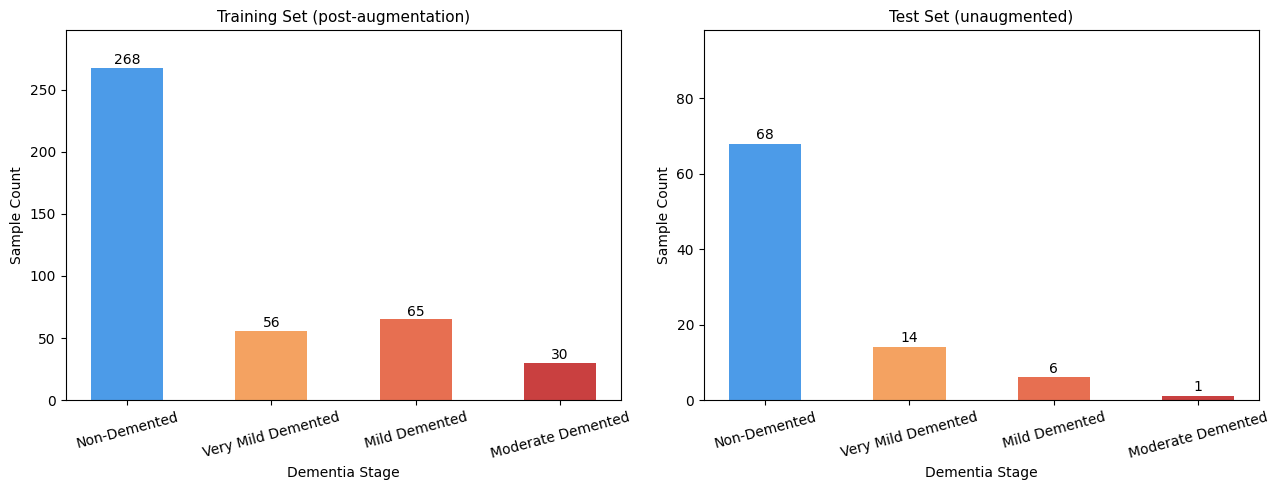


Final training set distribution:
  Non-Demented: 268
  Very Mild Demented: 56
  Mild Demented: 65
  Moderate Demented: 30

Final test set distribution:
  Non-Demented: 68
  Very Mild Demented: 14
  Mild Demented: 6
  Moderate Demented: 1


In [9]:
# Plotting training label distribution (post-augmentation)

train_counts = pd.Series(y_train).value_counts().reindex(LABEL_ORDER)
test_counts  = pd.Series(y_test).value_counts().reindex(LABEL_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4C9BE8', '#F4A261', '#E76F51', '#C94040']

for ax, counts, title in zip(
    axes,
    [train_counts, test_counts],
    ['Training Set (post-augmentation)', 'Test Set (unaugmented)']
):
    bars = ax.bar(LABEL_ORDER, counts.values, color=colors, width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                str(val), ha='center', va='bottom', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Dementia Stage')
    ax.set_ylabel('Sample Count')
    ax.set_ylim(0, counts.max() + 30)
    ax.tick_params(axis='x', labelrotation=15)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'train_distribution.png'), dpi=150)
plt.show()

print()
print('Final training set distribution:')
for label in LABEL_ORDER:
    print(f'  {label}: {train_counts[label]}')
print()
print('Final test set distribution:')
for label in LABEL_ORDER:
    print(f'  {label}: {test_counts[label]}')